# Reproduce release-derived paper results

This notebook reads in the released data, and show cases how to use the data to reproduce the tables and figures in the table.

Due to the difference in how the released dataset aggregates the different data sources, there is a slight difference (0.028 percentage points) compared to the original data used to derive the exact plots published in the paper.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

DATA = Path("federal_sealed_case_measurement_2020_2025.jsonl.gz")
if not DATA.exists():
    DATA = Path("imc-artifact") / DATA
assert DATA.exists(), DATA

In [2]:
# This is the notebook's only read of the compressed release.
cases = pd.read_json(
    DATA, lines=True, compression="gzip", convert_dates=False
)
print(f"Loaded {len(cases):,} rows and {len(cases.columns)} columns")
assert len(cases) == 612_001
assert len(cases.columns) == 28

cases.head()

Loaded 612,001 rows and 28 columns


,case_number,case_type,cmecf_filed_date,cmecf_sealed_title_pattern,courtlistener_docket_ids,courtlistener_earliest_filed_at,courtlistener_first_created_at,district_code,ecf_case_number_endpoint_status,ecf_notes,...,in_ecf_sealed,inferred_segment_end,inferred_segment_position,inferred_segment_start,is_source_only,known_alternate_case_type,matched_to_idb,observed_in_courtlistener,office,office_separate_numbers
0,1:20-CR-00001,cr,2020-01-13,NaN,"[44122660, 44122719]",2020-01-13T00:00:00Z,2021-01-27T01:48:15Z,gand,NaN,{'Division': 'Atlanta'},...,False,509.0,1.0,1.0,False,NaN,True,True,1.0,True
1,1:20-CR-00002,cr,2020-01-07,NaN,"[18242812, 44109666]",2020-01-07T00:00:00Z,2020-09-03T06:05:13Z,gand,NaN,{'Office': 'Atlanta'},...,False,509.0,2.0,1.0,False,NaN,False,True,1.0,True
2,1:20-CR-00003,cr,2020-01-07,NaN,"[44113321, 44113376]",2020-01-07T00:00:00Z,2021-01-27T01:37:42Z,gand,NaN,{'Office': 'Atlanta'},...,False,509.0,3.0,1.0,False,NaN,True,True,1.0,True
3,1:20-CR-00004,cr,2020-01-07,NaN,"[44112666, 44113001]",2020-01-07T00:00:00Z,2021-01-27T01:36:53Z,gand,NaN,{'Office': 'Atlanta'},...,False,509.0,4.0,1.0,False,NaN,True,True,1.0,True
4,1:20-CR-00005,cr,2020-01-07,NaN,"[44112946, 44112985]",2020-01-07T00:00:00Z,2021-01-27T01:37:12Z,gand,NaN,{'Office': 'Atlanta'},...,False,509.0,5.0,1.0,False,NaN,True,True,1.0,True


In [3]:
cases.columns

Index(['case_number', 'case_type', 'cmecf_filed_date',
       'cmecf_sealed_title_pattern', 'courtlistener_docket_ids',
       'courtlistener_earliest_filed_at', 'courtlistener_first_created_at',
       'district_code', 'ecf_case_number_endpoint_status', 'ecf_notes',
       'file_year', 'idb_case_numbers', 'idb_file_date',
       'idb_historical_sealing_flag', 'idb_linkage_method', 'idb_nos',
       'idb_proccd', 'in_ecf', 'in_ecf_sealed', 'inferred_segment_end',
       'inferred_segment_position', 'inferred_segment_start', 'is_source_only',
       'known_alternate_case_type', 'matched_to_idb',
       'observed_in_courtlistener', 'office', 'office_separate_numbers'],
      dtype='str')

In [4]:
# districts with reliable RSS coverage and thus CourtListener data (see paper for detail)
RELIABLE_DISTRICTS = {
    "prd", "ncwd", "lawd", "laed", "casd", "nvd", "ord",
    "waed", "okwd", "nysd", "txnd", "miwd", "ohnd", "insd",
}

# ranges of data collection
CASE_TYPES = ("cr", "cv", "mj")
YEARS = tuple(range(2020, 2026))

# visualization
DISTRICT_ORDER = [
    "prd", "nysd", "pawd", "scd", "ncwd", "lawd", "laed",
    "lamd", "txnd", "miwd", "ohnd", "ilsd", "insd", "casd",
    "nvd", "ord", "waed", "oknd", "okwd", "gand",
]
DISTRICT_LABELS = {
    "prd": ("D.", "Puerto Rico"),
    "nysd": ("S.D.", "New York"),
    "pawd": ("W.D.", "Pennsylvania"),
    "scd": ("D.", "South Carolina"),
    "ncwd": ("W.D.", "North Carolina"),
    "lawd": ("W.D.", "Louisiana"),
    "laed": ("E.D.", "Louisiana"),
    "lamd": ("M.D.", "Louisiana"),
    "txnd": ("N.D.", "Texas"),
    "miwd": ("W.D.", "Michigan"),
    "ohnd": ("N.D.", "Ohio"),
    "ilsd": ("S.D.", "Illinois"),
    "insd": ("S.D.", "Indiana"),
    "casd": ("S.D.", "California"),
    "nvd": ("D.", "Nevada*"),
    "ord": ("D.", "Oregon"),
    "waed": ("E.D.", "Washington"),
    "oknd": ("N.D.", "Oklahoma*"),
    "okwd": ("W.D.", "Oklahoma"),
    "gand": ("N.D.", "Georgia*"),
}

## Currently Sealed Cases Filed In 2023 (Table 3)

In this release, `in_ecf` means observed in the CM/ECF report as public and `in_ecf_sealed` means observed in the CM/ECF report as sealed. 
The hidden possible-case-number endpoint result is used when the case is omitted from reports.

The CourtListener numerator counts generated 2023 segment positions absent from CourtListener.
The denominator sums unique inclusive segment ranges. 
Known S.D. Illinois `pq` and E.D. Louisiana `mc` cases are removed from both the civil numerator and denominator (see details in paper)

In [5]:
rows_2023 = cases.loc[
    cases["file_year"].eq(2023) & cases["case_type"].isin(CASE_TYPES)
].copy()

segment_2023 = rows_2023.loc[~rows_2023["is_source_only"]].copy()
segment_2023["office_scope"] = segment_2023["office"].where(
    segment_2023["office_separate_numbers"], pd.NA
)
segment_ranges = segment_2023[[
    "district_code", "case_type", "office_scope",
    "inferred_segment_start", "inferred_segment_end",
]].drop_duplicates()
segment_ranges["segment_size"] = (
    segment_ranges["inferred_segment_end"]
    - segment_ranges["inferred_segment_start"] + 1
)
cl_segment_sizes = segment_ranges.groupby(
    ["district_code", "case_type"], dropna=False
)["segment_size"].sum()

missing_2023 = segment_2023.loc[
    ~segment_2023["observed_in_courtlistener"]
]
cl_missing_2023 = missing_2023.groupby(
    ["district_code", "case_type"]
).size()
cl_exclusions_2023 = missing_2023.loc[
    missing_2023["known_alternate_case_type"].notna()
].groupby(["district_code", "case_type"]).size()

cl_rows = []
for district in DISTRICT_ORDER:
    for case_type in ("cv", "cr", "mj"):
        key = (district, case_type)
        excluded = int(cl_exclusions_2023.get(key, 0))
        missing = int(cl_missing_2023.get(key, 0)) - excluded
        total = int(cl_segment_sizes.get(key, 0)) - excluded
        cl_rows.append({
            "district_code": district,
            "case_type": case_type,
            "missing": missing,
            "segment_size": total,
            "excluded_other_type": excluded,
            "cl_rate": missing / total,
        })
cl_table = pd.DataFrame(cl_rows)
cl_table

,district_code,case_type,missing,segment_size,excluded_other_type,cl_rate
0,prd,cv,28,633,0,0.044234
1,prd,cr,10,472,0,0.021186
2,prd,mj,952,1305,0,0.729502
3,nysd,cv,22,11329,0,0.001942
4,nysd,cr,34,683,0,0.049780
5,nysd,mj,4046,5480,0,0.738321
6,pawd,cv,6,2863,0,0.002096
7,pawd,cr,1,340,0,0.002941
8,pawd,mj,1380,1530,0,0.901961
9,scd,cv,112,7165,0,0.015632


In [6]:
ecf_source = rows_2023.loc[
    rows_2023["known_alternate_case_type"].isna()
].assign(
    endpoint_sealed=rows_2023[
        "ecf_case_number_endpoint_status"
    ].eq("sealed"),
    endpoint_unsealed=rows_2023[
        "ecf_case_number_endpoint_status"
    ].eq("unsealed"),
)

ecf_table = ecf_source.groupby(
    ["district_code", "case_type"], as_index=False
).agg(
    report_public=("in_ecf", "sum"),
    report_sealed=("in_ecf_sealed", "sum"),
    endpoint_sealed=("endpoint_sealed", "sum"),
    endpoint_unsealed=("endpoint_unsealed", "sum"),
)
ecf_table = ecf_table.loc[
    ecf_table["report_public"].add(ecf_table["report_sealed"]).gt(0)
].copy()

ecf_table["sealed"] = ecf_table[
    ["report_sealed", "endpoint_sealed"]
].max(axis=1)
ecf_table["public"] = (
    ecf_table["report_public"] + ecf_table["endpoint_unsealed"]
)
ecf_table["total"] = ecf_table["sealed"] + ecf_table["public"]
ecf_table["sealed_rate"] = ecf_table["sealed"] / ecf_table["total"]

ecf_table

,district_code,case_type,report_public,report_sealed,endpoint_sealed,endpoint_unsealed,sealed,public,total,sealed_rate
0,casd,cr,2779,21,10,1,21,2780,2801,0.007497
1,casd,cv,2363,8,7,0,8,2363,2371,0.003374
2,casd,mj,4329,1085,1090,0,1090,4329,5419,0.201144
3,gand,cr,499,0,0,0,0,499,499,0.000000
4,gand,cv,6850,17,0,0,17,6850,6867,0.002476
6,ilsd,cr,197,4,1,0,4,197,201,0.019900
7,ilsd,cv,1064,0,0,0,0,1064,1064,0.000000
8,ilsd,mj,49,309,142,0,309,49,358,0.863128
9,insd,cr,272,1,0,0,1,272,273,0.003663
10,insd,cv,3443,5,0,0,5,3443,3448,0.001450


In [7]:
ecf_lookup = ecf_table.set_index(["district_code", "case_type"])
cl_lookup = cl_table.set_index(["district_code", "case_type"])

table3_rows = []
for district in DISTRICT_ORDER:
    for case_type in ("cv", "cr", "mj"):
        key = (district, case_type)
        cl_rate = 100 * cl_lookup.loc[key, "cl_rate"]
        ecf_available = not (
            district == "gand" and case_type in {"cr", "mj"}
        )
        ecf_rate = (
            100 * ecf_lookup.loc[key, "sealed_rate"]
            if ecf_available and key in ecf_lookup.index else None
        )
        table3_rows.append({
            "district_code": district,
            "case_type": case_type,
            "ecf_rate": ecf_rate,
            "cl_rate": cl_rate,
            "diff_pp": None if ecf_rate is None else cl_rate - ecf_rate,
        })

table3_long = pd.DataFrame(table3_rows)
table3 = table3_long.pivot(
    index="district_code", columns="case_type",
    values=["ecf_rate", "cl_rate", "diff_pp"],
).reindex(DISTRICT_ORDER)
table3.columns = [f"{case_type}_{metric}" for metric, case_type in table3.columns]
table3 = table3.reset_index()

table3

,district_code,cr_ecf_rate,cv_ecf_rate,mj_ecf_rate,cr_cl_rate,cv_cl_rate,mj_cl_rate,cr_diff_pp,cv_diff_pp,mj_diff_pp
0,prd,2.320675,3.974563,73.814898,2.118644,4.423381,72.950192,-0.202031,0.448818,-0.864707
1,nysd,2.710843,0.185365,60.421286,4.978038,0.194192,73.832117,2.267195,0.008827,13.410831
2,pawd,0.000000,0.209570,92.299795,0.294118,0.209570,90.196078,0.294118,0.000000,-2.103716
3,scd,23.099704,0.113443,9.090909,25.670498,1.563154,10.869565,2.570794,1.449711,1.778656
4,ncwd,0.712589,0.348189,73.541667,2.336449,3.225806,75.717017,1.623860,2.877617,2.175351
5,lawd,0.694444,0.110497,7.407407,2.711864,1.147541,9.090909,2.017420,1.037044,1.683502
6,laed,1.052632,0.059997,34.848485,1.742160,9.161554,35.074627,0.689529,9.101557,0.226142
7,lamd,1.818182,0.059630,60.169492,4.464286,1.526718,60.504202,2.646104,1.467087,0.334710
8,txnd,1.033592,0.317020,71.812627,1.522843,2.038835,72.130487,0.489251,1.721815,0.317860
9,miwd,2.840909,0.000000,75.746924,3.932584,1.900674,77.813505,1.091675,1.900674,2.066580


In [8]:
computed_ecf_totals = {
    case_type: (int(group["sealed"].sum()), int(group["public"].sum()))
    for case_type, group in ecf_table.groupby("case_type")
}
computed_cl_totals = {
    case_type: (
        int(group["missing"].sum()), int(group["segment_size"].sum())
    )
    for case_type, group in cl_table.groupby("case_type")
}

table3_totals = []
for case_type in ("cv", "cr", "mj"):
    sealed, public = computed_ecf_totals[case_type]
    missing, total = computed_cl_totals[case_type]
    ecf_rate = 100 * sealed / (sealed + public)
    cl_rate = 100 * missing / total
    observed = (ecf_rate, cl_rate, cl_rate - ecf_rate)
    table3_totals.append({
        "case_type": case_type,
        "ecf_rate": ecf_rate,
        "cl_rate": cl_rate,
        "diff_pp": cl_rate - ecf_rate,
    })
table3_totals = pd.DataFrame(table3_totals)

table3_totals

,case_type,ecf_rate,cl_rate,diff_pp
0,cv,0.265715,1.999815,1.734100
1,cr,3.175027,4.067469,0.892442
2,mj,58.619531,61.245177,2.625646


## Historically sealed cases: fixed four-day threshold (Figure 1)

A currently unsealed CourtListener case is inferred to have been historically sealed when `courtlistener_first_created_at - courtlistener_earliest_filed_at > 4 days`.

In [9]:
historical_source = cases.loc[
    cases["case_type"].isin(CASE_TYPES)
    & cases["observed_in_courtlistener"]
].copy()
historical_source["created_at"] = pd.to_datetime(
    historical_source["courtlistener_first_created_at"],
    utc=True, errors="coerce",
)
historical_source["filed_at"] = pd.to_datetime(
    historical_source["courtlistener_earliest_filed_at"],
    utc=True, errors="coerce",
)
historical_source["delay_days"] = (
    historical_source["created_at"] - historical_source["filed_at"]
).dt.total_seconds() / 86_400
historical_source["is_historical"] = historical_source[
    "delay_days"
].gt(4).fillna(False)

four_day_rows = []
for case_type in CASE_TYPES:
    type_rows = historical_source.loc[
        historical_source["case_type"].eq(case_type)
    ]
    for scope, scope_rows in (
        ("all", type_rows),
        ("reliable", type_rows.loc[
            type_rows["district_code"].isin(RELIABLE_DISTRICTS)
        ]),
    ):
        historical = int(scope_rows["is_historical"].sum())
        total = len(scope_rows)
        four_day_rows.append({
            "case_type": case_type,
            "scope": scope,
            "historical": historical,
            "total": total,
            "rate": historical / total,
        })
four_day_table = pd.DataFrame(four_day_rows)
four_day_table

,case_type,scope,historical,total,rate
0,cr,all,19530,67680,0.288564
1,cr,reliable,9905,53839,0.183974
2,cv,all,89965,332443,0.270618
3,cv,reliable,29248,232429,0.125836
4,mj,all,15524,64184,0.241867
5,mj,reliable,10411,57895,0.179826


In [10]:
plot_source = historical_source.loc[
    historical_source["delay_days"].between(0, 60, inclusive="both")
].copy()
cl_plot = plot_source.groupby(
    ["district_code", "file_year", "case_type"]
).agg(
    cl_historical=("is_historical", "sum"),
    cl_total=("case_number", "size"),
)
idb_plot = plot_source.loc[
    plot_source["matched_to_idb"]
    & plot_source["idb_historical_sealing_flag"].notna()
].groupby(["district_code", "file_year", "case_type"]).agg(
    idb_historical=("idb_historical_sealing_flag", "sum"),
    idb_total=("case_number", "size"),
)

historical_index = pd.MultiIndex.from_product(
    [DISTRICT_ORDER, YEARS, CASE_TYPES],
    names=["district_code", "file_year", "case_type"],
)
historical_table = cl_plot.join(idb_plot, how="outer").reindex(
    historical_index
)
for column in (
    "cl_historical", "cl_total", "idb_historical", "idb_total"
):
    historical_table[column] = historical_table[column].fillna(0).astype(int)
historical_table["cl_rate"] = (
    historical_table["cl_historical"] / historical_table["cl_total"]
).where(historical_table["cl_total"].gt(0))
historical_table["idb_rate"] = (
    historical_table["idb_historical"] / historical_table["idb_total"]
).where(historical_table["idb_total"].gt(0))
historical_table = historical_table.reset_index()

historical_table

,district_code,file_year,case_type,cl_historical,cl_total,idb_historical,idb_total,cl_rate,idb_rate
0,prd,2020,cr,134,432,43,387,0.310185,0.111111
1,prd,2020,cv,43,732,1,723,0.058743,0.001383
2,prd,2020,mj,161,546,0,0,0.294872,NaN
3,prd,2021,cr,128,476,82,451,0.268908,0.181818
4,prd,2021,cv,36,618,1,610,0.058252,0.001639
...,...,...,...,...,...,...,...,...,...
355,gand,2024,cv,766,2688,3,2677,0.284970,0.001121
356,gand,2024,mj,10,22,0,0,0.454545,NaN
357,gand,2025,cr,169,183,5,147,0.923497,0.034014
358,gand,2025,cv,1310,2336,19,2305,0.560788,0.008243


In [11]:
idb_observed_source = cases.loc[
    cases["case_type"].isin({"cr", "cv"})
    & cases["observed_in_courtlistener"]
    & cases["matched_to_idb"]
]
idb_table = idb_observed_source.groupby("case_type", as_index=False).agg(
    historically_sealed=("idb_historical_sealing_flag", "sum"),
    observed_in_cl_and_idb=("case_number", "size"),
)
idb_table["rate"] = (
    idb_table["historically_sealed"]
    / idb_table["observed_in_cl_and_idb"]
)

idb_table

,case_type,historically_sealed,observed_in_cl_and_idb,rate
0,cr,10477.0,57002,0.183801
1,cv,278.0,328544,0.000846


In [12]:
segment_rows = cases.loc[~cases["is_source_only"]]
segment_summary = pd.Series({
    "positions": len(segment_rows),
    "observed_in_courtlistener": int(
        segment_rows["observed_in_courtlistener"].sum()
    ),
}, name="count")
segment_summary

positions                    577659
observed_in_courtlistener    464307
Name: count, dtype: int64

### Plot

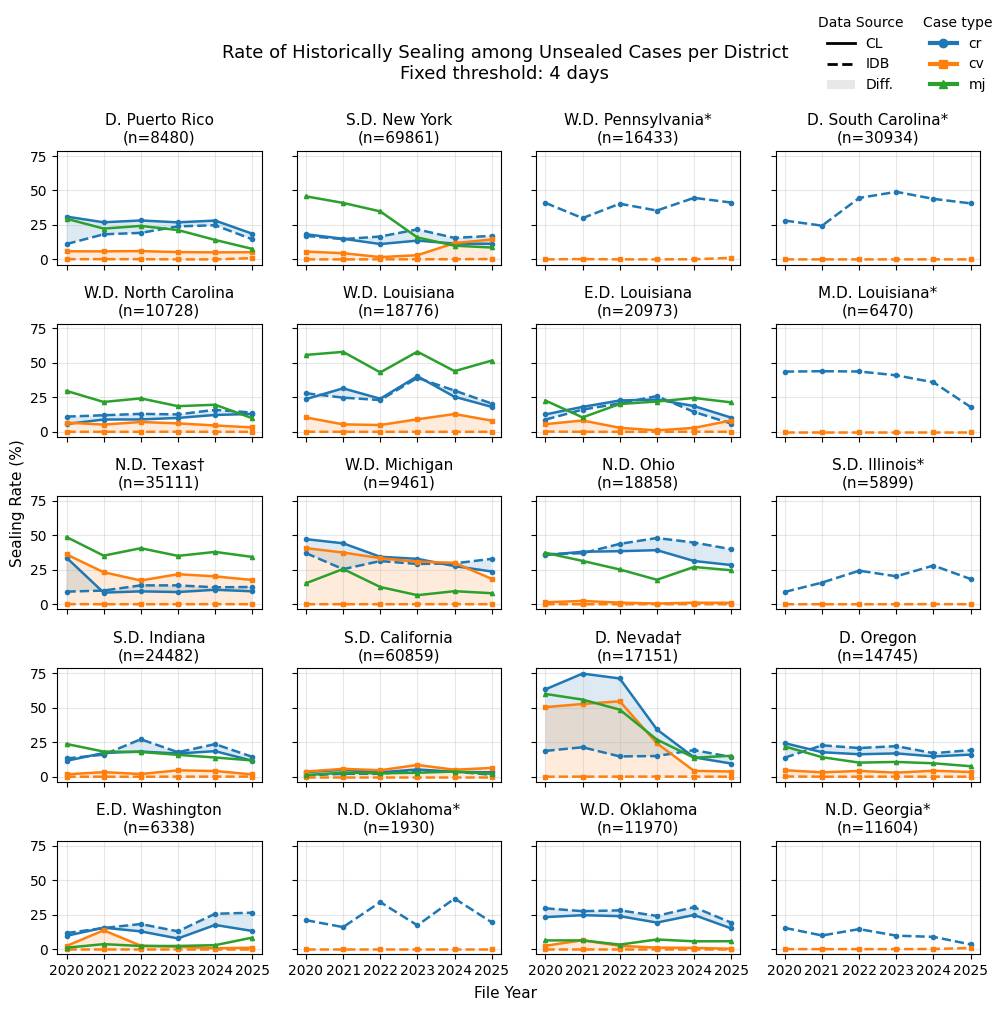

In [13]:
colors = {"cr": "#1f77b4", "cv": "#ff7f0e", "mj": "#2ca02c"}
markers = {"cr": "o", "cv": "s", "mj": "^"}
fig, axes = plt.subplots(5, 4, figsize=(10, 10), sharex=True, sharey=True)
for ax, district in zip(axes.ravel(), DISTRICT_ORDER):
    district_rows = historical_table.loc[
        historical_table["district_code"].eq(district)
    ]
    for case_type in CASE_TYPES:
        values = district_rows.loc[
            district_rows["case_type"].eq(case_type)
        ].sort_values("file_year")
        style = dict(
            color=colors[case_type], marker=markers[case_type],
            linewidth=1.8, markersize=3,
        )
        if district in RELIABLE_DISTRICTS:
            ax.plot(
                values["file_year"], values["cl_rate"] * 100,
                linestyle="-", **style,
            )
        if case_type in {"cr", "cv"} and values["idb_rate"].notna().any():
            ax.plot(
                values["file_year"], values["idb_rate"] * 100,
                linestyle="--", **style,
            )
            if district in RELIABLE_DISTRICTS:
                mask = values["cl_rate"].notna() & values["idb_rate"].notna()
                ax.fill_between(
                    values.loc[mask, "file_year"],
                    values.loc[mask, "cl_rate"] * 100,
                    values.loc[mask, "idb_rate"] * 100,
                    alpha=0.15, interpolate=True,
                )
    prefix, name = DISTRICT_LABELS[district]
    name = name.rstrip("*")
    marker = r"$\dagger$" if district in {"nvd", "txnd"} else (
        "*" if district not in RELIABLE_DISTRICTS else ""
    )
    panel_n = int(district_rows["cl_total"].sum())
    ax.set_title(f"{prefix} {name}{marker}\n(n={panel_n})", fontsize=11)
    ax.set_xticks(YEARS)
    ax.grid(True, alpha=0.3)

case_legend = [
    Line2D([0], [0], color=colors[case_type], marker=markers[case_type],
           lw=3, label=case_type)
    for case_type in CASE_TYPES
]
source_legend = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="CL"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="IDB"),
    Patch(facecolor="gray", alpha=0.18, label="Diff."),
]
fig.legend(handles=case_legend, loc="upper right", bbox_to_anchor=(1, 1),
           frameon=False, title="Case type")
fig.legend(handles=source_legend, loc="upper left", bbox_to_anchor=(0.8, 1),
           frameon=False, title="Data Source")
fig.suptitle(
    "\nRate of Historically Sealing among Unsealed Cases per District\n"
    "Fixed threshold: 4 days\n", fontsize=13,
)
fig.text(0.5, 0.005, "File Year", ha="center", fontsize=11)
fig.text(0.005, 0.5, "Sealing Rate (%)", va="center",
         rotation="vertical", fontsize=11)
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.tight_layout(rect=[0.01, 0.01, 1, 1])
plt.show()

## Time under seal: Kaplan-Meier survival curves (Figure 2)

In [14]:
# time of data collection
CENSOR_AT = pd.Timestamp("2025-09-25T00:00:00Z").tz_localize(None)
survival = cases.loc[
    cases["case_type"].isin({"cr", "cv"})
    & cases["matched_to_idb"]
    & cases["idb_historical_sealing_flag"].eq(True)
    & cases["idb_file_date"].notna(),
    [
        "district_code", "case_type", "case_number",
        "idb_file_date", "courtlistener_first_created_at",
    ],
].copy()

survival["filed_date"] = pd.to_datetime(
    survival["idb_file_date"], errors="coerce"
)
created_utc = pd.to_datetime(
    survival["courtlistener_first_created_at"], utc=True, errors="coerce"
)
created_naive = (
    created_utc.dt.tz_convert("America/New_York").dt.tz_localize(None)
)
survival["event_observed"] = created_naive.notna()
survival["event_duration_days"] = (
    (created_naive - survival["filed_date"]).dt.total_seconds() / 86_400
)
elapsed_days = (
    (CENSOR_AT - survival["filed_date"]).dt.total_seconds() / 86_400
)
survival["duration_days"] = elapsed_days
survival.loc[
    survival["event_observed"], "duration_days"
] = survival.loc[survival["event_observed"], "event_duration_days"]
survival = survival.loc[
    survival["filed_date"].notna() & survival["duration_days"].notna()
].copy()
survival["duration_days"] = survival["duration_days"].clip(lower=0)
elapsed_days = (
    (CENSOR_AT - survival["filed_date"]).dt.total_seconds() / 86_400
)

impossible_event = (
    survival["event_observed"]
    & survival["duration_days"].gt(elapsed_days)
)
survival.loc[impossible_event, "duration_days"] = elapsed_days.loc[
    impossible_event
]

survival_results = survival.groupby(
    ["district_code", "case_type"], as_index=False
).agg(
    observations=("duration_days", "size"),
    unsealed_events=("event_observed", "sum"),
)

survival_results

,district_code,case_type,observations,unsealed_events
0,casd,cr,609,538
1,casd,cv,41,7
2,gand,cr,240,230
3,gand,cv,189,68
4,ilsd,cr,296,280
5,ilsd,cv,12,1
6,insd,cr,337,324
7,insd,cv,35,9
8,laed,cr,286,271
9,laed,cv,19,8


### Plot

In [15]:
observed_survival_counts = {
    district: tuple(
        int(((survival["district_code"] == district)
             & (survival["case_type"] == case_type)).sum())
        for case_type in ("cr", "cv")
    )
    for district in DISTRICT_ORDER
}
observed_survival_counts

{'prd': (599, 22),
 'nysd': (621, 207),
 'pawd': (821, 73),
 'scd': (890, 64),
 'ncwd': (322, 34),
 'lawd': (495, 15),
 'laed': (286, 19),
 'lamd': (236, 6),
 'txnd': (846, 157),
 'miwd': (416, 15),
 'ohnd': (1577, 32),
 'ilsd': (296, 12),
 'insd': (337, 35),
 'casd': (609, 41),
 'nvd': (294, 132),
 'ord': (584, 46),
 'waed': (311, 30),
 'oknd': (652, 16),
 'okwd': (713, 22),
 'gand': (240, 189)}

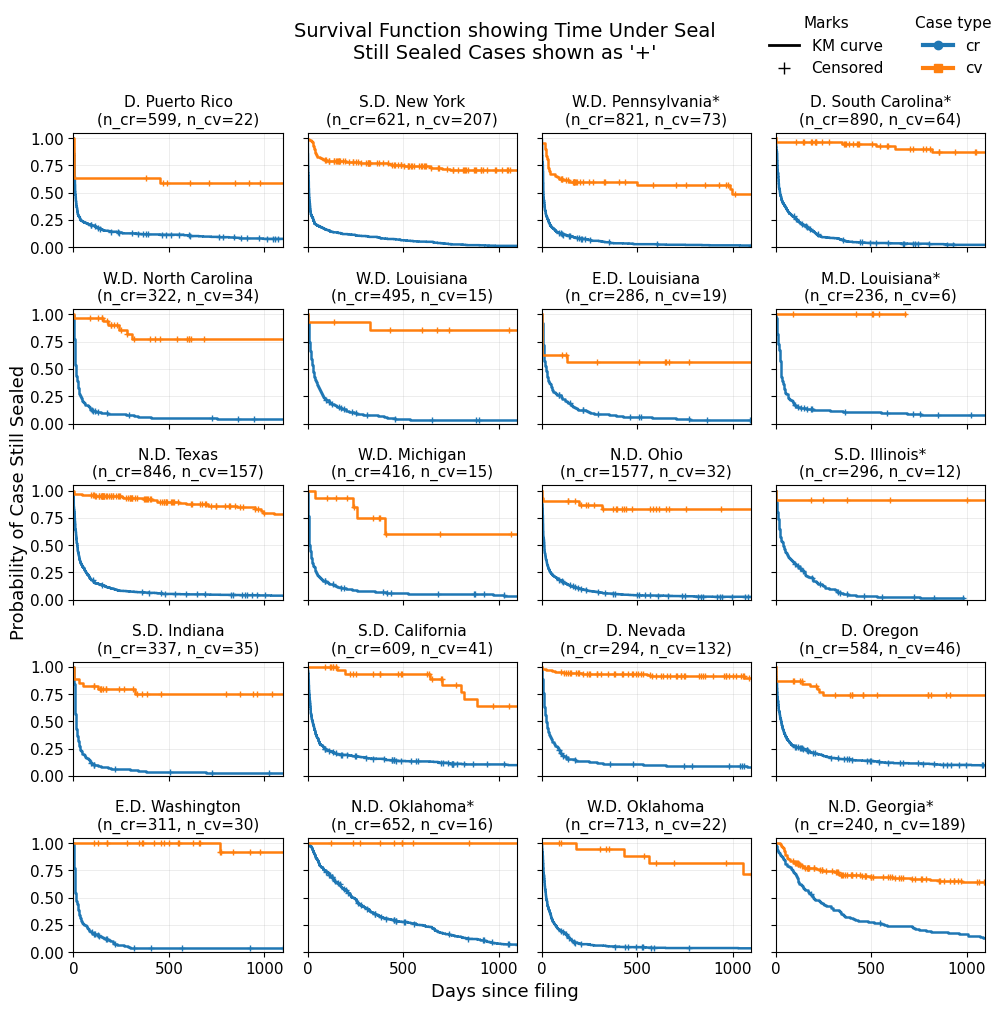

In [16]:
colors = {"cr": "#1f77b4", "cv": "#ff7f0e"}
markers = {"cr": "o", "cv": "s"}
fig, axes = plt.subplots(5, 4, figsize=(10, 10), sharex=True, sharey=True)
for ax, district in zip(axes.ravel(), DISTRICT_ORDER):
    district_rows = survival.loc[survival["district_code"].eq(district)]
    for case_type in ("cr", "cv"):
        values = district_rows.loc[
            district_rows["case_type"].eq(case_type)
        ]
        if values.empty:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=values["duration_days"],
            event_observed=values["event_observed"],
            label=case_type,
        )
        kmf.plot(
            ax=ax, ci_show=False, show_censors=True,
            censor_styles={"marker": "+", "ms": 5},
            color=colors[case_type], linewidth=1.8,
        )
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    prefix, name = DISTRICT_LABELS[district]
    name = name.rstrip("*")
    bad_marker = "*" if district not in RELIABLE_DISTRICTS else ""
    n_cr, n_cv = observed_survival_counts[district]
    ax.set_title(
        f"{prefix} {name}{bad_marker}\n(n_cr={n_cr}, n_cv={n_cv})",
        fontsize=11,
    )
    ax.grid(True, linewidth=0.4, alpha=0.4)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xlabel("")
    ax.set_xlim(0, 1095)
    ax.tick_params(axis="both", labelsize=11)

case_legend = [
    Line2D([0], [0], color=colors[case_type], marker=markers[case_type],
           lw=3, label=case_type)
    for case_type in ("cr", "cv")
]
mark_legend = [
    Line2D([0], [0], color="black", lw=2, label="KM curve"),
    Line2D([0], [0], color="black", lw=0, marker="+",
           label="Censored", markersize=8),
]
fig.legend(handles=case_legend, loc="upper right", bbox_to_anchor=(1, 1),
           frameon=False, title="Case type", fontsize=11,
           title_fontsize=11)
fig.legend(handles=mark_legend, loc="upper left", bbox_to_anchor=(0.75, 1),
           frameon=False, title="Marks", fontsize=11,
           title_fontsize=11)
fig.suptitle(
    "Survival Function showing Time Under Seal\n"
    "Still Sealed Cases shown as '+'\n", fontsize=14,
)
fig.text(0.5, 0.005, "Days since filing", ha="center", fontsize=13)
fig.text(0.005, 0.5, "Probability of Case Still Sealed", va="center",
         rotation="vertical", fontsize=13)
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.tight_layout(rect=[0.01, 0.01, 1, 1])

plt.show()